# DreamZero Video / Action 联合去噪调试

这个 Notebook 将 `DreamZeroHead._sample_action_block()` 拆成可观察、可单步执行的流程，重点检查：

- Video latent 与 Action 的独立高斯噪声初始化；
- 两套 `FlowUniPCMultistepScheduler` 的 timestep / sigma；
- `decouple_inference_noise` 与 `video_inference_final_noise` 的影响；
- 每一步模型 flow prediction、样本统计和数值稳定性；
- 如何把可控 oracle/mock predictor 替换成真实 DreamZero 模型。

默认只使用小张量和解析的“完美 flow oracle”，**不会加载 14B DiT 权重**。

## 1. 导入依赖并加载 DreamZero 组件

仓库中的 `FlowUniPCMultistepScheduler.__init__()` 当前会在 CUDA 上创建训练 sigma，因此本 Notebook 使用 CUDA。`DreamZeroHead` 只导入类定义，不实例化大模型。

In [1]:
from pathlib import Path
import random
import sys
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import torch


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "fluxvla").is_dir() and (candidate / "configs").is_dir():
            return candidate
    fallback = Path("/root/projects/fluxvla")
    if fallback.is_dir():
        return fallback
    raise FileNotFoundError("找不到 fluxvla 项目根目录")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from fluxvla.models.heads.dreamzero_head import DreamZeroHead
from fluxvla.models.third_party_models.dreamzero.modules.flow_unipc_multistep_scheduler import (
    FlowUniPCMultistepScheduler,
)

assert torch.cuda.is_available(), (
    "当前 FlowUniPCMultistepScheduler.__init__() 在 CUDA 上创建 sigma；"
    "请选择可用 CUDA 的 Notebook kernel。"
)
DEVICE = torch.device("cuda")
BF16_SUPPORTED = torch.cuda.is_bf16_supported()
LATENT_DTYPE = torch.bfloat16 if BF16_SUPPORTED else torch.float32
COMPUTE_DTYPE = torch.float32


def seed_everything(seed: int = 7) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(7)
torch.set_printoptions(precision=5, sci_mode=False)

print(f"project_root: {PROJECT_ROOT}")
print(f"torch: {torch.__version__}")
print(f"device: {DEVICE} ({torch.cuda.get_device_name(DEVICE)})")
print(f"bf16_supported: {BF16_SUPPORTED}, latent_dtype: {LATENT_DTYPE}")
print(f"DreamZeroHead source: {PROJECT_ROOT / 'fluxvla/models/heads/dreamzero_head.py'}")

07/22 [04:05:43] INFO     | >> TensorFlow version 2.15.0 available.                                   ]8;id=14782905;file:///root/miniconda3/lib/python3.10/site-packages/datasets/config.py\config.py]8;;\:]8;id=14782906;file:///root/miniconda3/lib/python3.10/site-packages/datasets/config.py#112\112]8;;\

                 INFO     | >> JAX version 0.6.2 available.                                           ]8;id=14782912;file:///root/miniconda3/lib/python3.10/site-packages/datasets/config.py\config.py]8;;\:]8;id=14782913;file:///root/miniconda3/lib/python3.10/site-packages/datasets/config.py#125\125]8;;\

project_root: /root/projects/fluxvla
torch: 2.6.0+cu124
device: cuda (NVIDIA A100-SXM4-80GB)
bf16_supported: True, latent_dtype: torch.bfloat16
DreamZeroHead source: /root/projects/fluxvla/fluxvla/models/heads/dreamzero_head.py


## 2. 构造最小化调试配置与模拟输入

这里只保留 `_sample_action_block()` 的数据契约。`mock/oracle predictor` 不读取语言、图像条件和 cache，因此可以检查控制流而不分配 14B 模型。

In [2]:
from dataclasses import dataclass


@dataclass(frozen=True)
class DebugConfig:
    batch_size: int = 1
    num_channels: int = 16
    denoise_frames: int = 2
    latent_height: int = 8
    latent_width: int = 8
    action_horizon: int = 10
    action_dim: int = 7
    max_action_dim: int = 32
    max_state_dim: int = 64
    num_inference_steps: int = 4
    num_train_timesteps: int = 1000
    shift: float = 5.0
    video_final_noise: float = 0.8


CFG = DebugConfig()
B = CFG.batch_size

# 条件输入只用于保持 DreamZero 的接口与形状语义；mock predictor 不使用它们。
prompt_embs = torch.zeros(B, 512, 4096, device=DEVICE, dtype=LATENT_DTYPE)
clip_feas = torch.zeros(B, 257, 1280, device=DEVICE, dtype=LATENT_DTYPE)
ys = torch.zeros(
    B, 20, CFG.denoise_frames, CFG.latent_height, CFG.latent_width,
    device=DEVICE, dtype=LATENT_DTYPE,
)
states = torch.zeros(B, 1, CFG.max_state_dim, device=DEVICE, dtype=LATENT_DTYPE)
embodiment_ids = torch.zeros(B, device=DEVICE, dtype=torch.long)

# 小型占位 cache，仅用于观察接口；真实 Wan 14B cache 的层数和 head 维度会更大。
kv_cache = [torch.zeros(2, B, 0, 4, 8, device=DEVICE, dtype=LATENT_DTYPE)]
crossattn_cache = [torch.zeros(2, B, 8, 4, 8, device=DEVICE, dtype=LATENT_DTYPE)]

video_shape = (
    B, CFG.num_channels, CFG.denoise_frames,
    CFG.latent_height, CFG.latent_width,
)
action_shape = (B, CFG.action_horizon, CFG.max_action_dim)

# 解析目标：Video 使用平滑网格；Action 只有前 action_dim 维有效，其余 padding 为 0。
clean_video_latents = torch.linspace(
    -1.0, 1.0, int(np.prod(video_shape)), device=DEVICE, dtype=COMPUTE_DTYPE
).reshape(video_shape)
clean_actions = torch.zeros(action_shape, device=DEVICE, dtype=COMPUTE_DTYPE)
time_axis = torch.linspace(0, 1, CFG.action_horizon, device=DEVICE)
for dim in range(CFG.action_dim):
    clean_actions[0, :, dim] = torch.sin((dim + 1) * torch.pi * time_axis) / (dim + 1)

named_tensors = {
    "prompt_embs": prompt_embs,
    "clip_feas": clip_feas,
    "ys": ys,
    "states": states,
    "embodiment_ids": embodiment_ids,
    "kv_cache[0]": kv_cache[0],
    "crossattn_cache[0]": crossattn_cache[0],
    "clean_video_latents": clean_video_latents,
    "clean_actions": clean_actions,
}
for name, tensor in named_tensors.items():
    print(f"{name:24s} shape={tuple(tensor.shape)!s:24s} dtype={str(tensor.dtype):14s} device={tensor.device}")

prompt_embs              shape=(1, 512, 4096)           dtype=torch.bfloat16 device=cuda:0
clip_feas                shape=(1, 257, 1280)           dtype=torch.bfloat16 device=cuda:0
ys                       shape=(1, 20, 2, 8, 8)         dtype=torch.bfloat16 device=cuda:0
states                   shape=(1, 1, 64)               dtype=torch.bfloat16 device=cuda:0
embodiment_ids           shape=(1,)                     dtype=torch.int64    device=cuda:0
kv_cache[0]              shape=(2, 1, 0, 4, 8)          dtype=torch.bfloat16 device=cuda:0
crossattn_cache[0]       shape=(2, 1, 8, 4, 8)          dtype=torch.bfloat16 device=cuda:0
clean_video_latents      shape=(1, 16, 2, 8, 8)         dtype=torch.float32  device=cuda:0
clean_actions            shape=(1, 10, 32)              dtype=torch.float32  device=cuda:0


## 3. 初始化 Video 与 Action 噪声

下面两次 `torch.randn()` 对应 `_sample_action_block()` 中的 `noisy_latents` 和 `noisy_actions`。两种模态共享去噪循环，但初始噪声彼此独立。

In [3]:
def tensor_stats(name: str, tensor: torch.Tensor) -> dict:
    x = tensor.detach().float()
    stats = {
        "name": name,
        "shape": tuple(tensor.shape),
        "dtype": str(tensor.dtype),
        "device": str(tensor.device),
        "mean": x.mean().item(),
        "std": x.std().item(),
        "min": x.min().item(),
        "max": x.max().item(),
        "l2": x.norm().item(),
        "finite": bool(torch.isfinite(x).all()),
    }
    print(
        f"{name:18s} shape={stats['shape']} mean={stats['mean']:+.5f} "
        f"std={stats['std']:.5f} min={stats['min']:+.5f} "
        f"max={stats['max']:+.5f} L2={stats['l2']:.5f} finite={stats['finite']}"
    )
    return stats


seed_everything(7)
video_noise = torch.randn(video_shape, device=DEVICE, dtype=LATENT_DTYPE)
action_noise = torch.randn(action_shape, device=DEVICE, dtype=LATENT_DTYPE)

# 与 head 中的变量命名一致：推理起点是纯高斯噪声。
noisy_latents_init = video_noise.clone()
noisy_actions_init = action_noise.clone()

assert noisy_latents_init.shape == video_shape
assert noisy_actions_init.shape == action_shape
assert noisy_latents_init.data_ptr() != noisy_actions_init.data_ptr()
assert torch.isfinite(noisy_latents_init).all()
assert torch.isfinite(noisy_actions_init).all()

video_init_stats = tensor_stats("noisy_latents", noisy_latents_init)
action_init_stats = tensor_stats("noisy_actions", noisy_actions_init)

noisy_latents      shape=(1, 16, 2, 8, 8) mean=-0.00455 std=1.01273 min=-3.71875 max=+3.34375 L2=45.82019 finite=True
noisy_actions      shape=(1, 10, 32) mean=+0.03600 std=1.00598 min=-3.20312 max=+2.82812 L2=17.97900 finite=True


## 4. 配置 Video 与 Action 去噪调度器

DreamZero 创建两个独立 scheduler 实例。未解耦时，它们的配置、timesteps 和 sigmas 完全一致；分成两个实例是因为 UniPC 各自维护历史状态。

In [4]:
def make_scheduler() -> FlowUniPCMultistepScheduler:
    scheduler = FlowUniPCMultistepScheduler(
        num_train_timesteps=CFG.num_train_timesteps,
        shift=1,
        use_dynamic_shifting=False,
    )
    scheduler.set_timesteps(
        CFG.num_inference_steps,
        device=DEVICE,
        shift=CFG.shift,
    )
    return scheduler


def make_scheduler_pair() -> tuple[FlowUniPCMultistepScheduler, FlowUniPCMultistepScheduler]:
    return make_scheduler(), make_scheduler()


sample_scheduler, sample_scheduler_action = make_scheduler_pair()

print("video timesteps:", sample_scheduler.timesteps)
print("action timesteps:", sample_scheduler_action.timesteps)
print("video sigmas:", sample_scheduler.sigmas)
print("action sigmas:", sample_scheduler_action.sigmas)
print("num timesteps:", len(sample_scheduler.timesteps))
print("num sigmas (含最终边界):", len(sample_scheduler.sigmas))
print("sigma bounds:", sample_scheduler.sigmas[0].item(), "->", sample_scheduler.sigmas[-1].item())

assert torch.equal(sample_scheduler.timesteps, sample_scheduler_action.timesteps)
assert torch.allclose(sample_scheduler.sigmas, sample_scheduler_action.sigmas)
assert len(sample_scheduler.sigmas) == len(sample_scheduler.timesteps) + 1

video timesteps: tensor([999, 937, 833, 624], device='cuda:0')
action timesteps: tensor([999, 937, 833, 624], device='cuda:0')
video sigmas: tensor([0.99980, 0.93727, 0.83306, 0.62469, 0.00000], device='cuda:0')
action sigmas: tensor([0.99980, 0.93727, 0.83306, 0.62469, 0.00000], device='cuda:0')
num timesteps: 4
num sigmas (含最终边界): 5
sigma bounds: 0.9997998476028442 -> 0.0


## 5. 调试 `video_final_noise` 与 Sigma 重映射

严格复现源码中的仿射变换：

$$\sigma'_v=\sigma_v\frac{\sigma_{\max}-\sigma_{\mathrm{final}}}{\sigma_{\max}}+\sigma_{\mathrm{final}}$$

这样 Video 的终点从 $0$ 改为 `video_final_noise`，Action 仍到 $0$。

In [5]:
def remap_video_schedule(
    scheduler: FlowUniPCMultistepScheduler,
    video_final_noise: float,
) -> torch.Tensor:
    sigma_max = float(scheduler.sigmas[0].item())
    if not 0.0 <= video_final_noise < sigma_max:
        raise ValueError(
            f"video_final_noise 必须满足 0 <= value < sigma_max({sigma_max:.6f})，"
            f"当前为 {video_final_noise}"
        )

    original_sigmas = scheduler.sigmas.clone()
    scheduler.sigmas = (
        scheduler.sigmas
        * (sigma_max - video_final_noise)
        / sigma_max
        + video_final_noise
    )
    scheduler.timesteps = (
        scheduler.sigmas[:-1] * CFG.num_train_timesteps
    ).to(torch.int64)
    return original_sigmas


video_scheduler_decoupled, action_scheduler_decoupled = make_scheduler_pair()
original_video_sigmas = remap_video_schedule(
    video_scheduler_decoupled,
    CFG.video_final_noise,
)

print("step | video sigma: current -> next | action sigma: current -> next | t_video | t_action")
for i in range(CFG.num_inference_steps):
    print(
        f"{i:>4d} | "
        f"{video_scheduler_decoupled.sigmas[i].item():.6f} -> "
        f"{video_scheduler_decoupled.sigmas[i + 1].item():.6f} | "
        f"{action_scheduler_decoupled.sigmas[i].item():.6f} -> "
        f"{action_scheduler_decoupled.sigmas[i + 1].item():.6f} | "
        f"{video_scheduler_decoupled.timesteps[i].item():>7d} | "
        f"{action_scheduler_decoupled.timesteps[i].item():>7d}"
    )

assert torch.allclose(original_video_sigmas, action_scheduler_decoupled.sigmas)
assert torch.isclose(
    video_scheduler_decoupled.sigmas[-1],
    torch.tensor(CFG.video_final_noise, device=DEVICE),
)
assert action_scheduler_decoupled.sigmas[-1].item() == 0.0
assert not torch.equal(
    video_scheduler_decoupled.timesteps,
    action_scheduler_decoupled.timesteps,
)

step | video sigma: current -> next | action sigma: current -> next | t_video | t_action
   0 | 0.999800 -> 0.987303 | 0.999800 -> 0.937265 |     999 |     999
   1 | 0.987303 -> 0.966478 | 0.937265 -> 0.833055 |     987 |     937
   2 | 0.966478 -> 0.924837 | 0.833055 -> 0.624687 |     966 |     833
   3 | 0.924837 -> 0.800000 | 0.624687 -> 0.000000 |     924 |     624


## 6. 逐步执行联合 Video / Action 去噪

`denoise_loop()` 保留源码中的关键变量与顺序。默认 predictor 是解析 oracle：

$$v_v=\epsilon_v-z_v,\qquad v_a=\epsilon_a-a$$

真实 DiT 接入时，只需让 callback 返回 `(video_flow_cond, action_flow_cond, video_flow_uncond)`。Action 与源码一致只使用 conditional prediction；CFG 只作用于 Video。

In [8]:
FlowPredictor = Callable[
    [torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, int, float, float],
    tuple[torch.Tensor, torch.Tensor, torch.Tensor],
]


def oracle_flow_predictor(
    noisy_latents: torch.Tensor,
    noisy_actions: torch.Tensor,
    t_video: torch.Tensor,
    t_action: torch.Tensor,
    step_index: int,
    video_sigma: float,
    action_sigma: float,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    del noisy_latents, noisy_actions, t_video, t_action, step_index, video_sigma, action_sigma
    video_flow_cond = video_noise.float() - clean_video_latents
    action_flow_cond = action_noise.float() - clean_actions
    # 令 unconditional 与 conditional 相同，使 CFG 分支可执行但不改变解析 oracle。
    video_flow_uncond = video_flow_cond.clone()
    return video_flow_cond, action_flow_cond, video_flow_uncond


def denoise_loop(
    predict_flow: FlowPredictor = oracle_flow_predictor,
    *,
    decouple_inference_noise: bool = False,
    video_final_noise: float = 0.0,
    cfg_scale: float = 5.0,
    initial_latents: torch.Tensor | None = None,
    initial_actions: torch.Tensor | None = None,
    verbose: bool = True,
) -> dict:
    video_scheduler, action_scheduler = make_scheduler_pair()
    if decouple_inference_noise:
        remap_video_schedule(video_scheduler, video_final_noise)

    noisy_latents = (
        noisy_latents_init if initial_latents is None else initial_latents
    ).clone().float()
    noisy_actions = (
        noisy_actions_init if initial_actions is None else initial_actions
    ).clone().float()
    history: list[dict] = []

    for step_index in range(len(video_scheduler.timesteps)):
        video_timestep = video_scheduler.timesteps[step_index]
        action_timestep = action_scheduler.timesteps[step_index]
        video_sigma = float(video_scheduler.sigmas[step_index].item())
        action_sigma = float(action_scheduler.sigmas[step_index].item())
        next_video_sigma = float(video_scheduler.sigmas[step_index + 1].item())
        next_action_sigma = float(action_scheduler.sigmas[step_index + 1].item())

        t_video = video_timestep.expand(B, CFG.denoise_frames)
        t_action = action_timestep.expand(B, CFG.action_horizon)

        video_flow_cond, action_flow_cond, video_flow_uncond = predict_flow(
            noisy_latents,
            noisy_actions,
            t_video,
            t_action,
            step_index,
            video_sigma,
            action_sigma,
        )
        video_flow_pred = video_flow_uncond + cfg_scale * (
            video_flow_cond - video_flow_uncond
        )
        action_flow_pred = action_flow_cond

        assert video_flow_pred.shape == noisy_latents.shape
        assert action_flow_pred.shape == noisy_actions.shape
        assert video_flow_pred.device == noisy_latents.device
        assert action_flow_pred.device == noisy_actions.device
        assert noisy_latents.device.type == noisy_actions.device.type == "cuda"
        assert torch.isfinite(video_flow_pred).all()
        assert torch.isfinite(action_flow_pred).all()

        noisy_latents = video_scheduler.step(
            model_output=video_flow_pred.float(),
            timestep=video_timestep,
            sample=noisy_latents.float(),
            step_index=step_index,
            return_dict=False,
        )[0]
        noisy_actions = action_scheduler.step(
            model_output=action_flow_pred.float(),
            timestep=action_timestep,
            sample=noisy_actions.float(),
            step_index=step_index,
            return_dict=False,
        )[0]

        assert noisy_latents.shape == video_shape
        assert noisy_actions.shape == action_shape
        assert noisy_latents.dtype == noisy_actions.dtype == COMPUTE_DTYPE
        assert torch.isfinite(noisy_latents).all()
        assert torch.isfinite(noisy_actions).all()

        row = {
            "step": step_index,
            "video_timestep": int(video_timestep.item()),
            "action_timestep": int(action_timestep.item()),
            "video_sigma": video_sigma,
            "action_sigma": action_sigma,
            "next_video_sigma": next_video_sigma,
            "next_action_sigma": next_action_sigma,
            "video_pred_l2": float(video_flow_pred.norm().item()),
            "action_pred_l2": float(action_flow_pred.norm().item()),
            "video_mean": float(noisy_latents.mean().item()),
            "video_std": float(noisy_latents.std().item()),
            "video_l2": float(noisy_latents.norm().item()),
            "action_mean": float(noisy_actions.mean().item()),
            "action_std": float(noisy_actions.std().item()),
            "action_l2": float(noisy_actions.norm().item()),
            "video_mse_to_clean": float(
                torch.mean((noisy_latents - clean_video_latents) ** 2).item()
            ),
            "action_mse_to_clean": float(
                torch.mean((noisy_actions - clean_actions) ** 2).item()
            ),
            "action_0": noisy_actions[0, 0, :CFG.action_dim].detach().cpu().numpy().copy(),
        }
        history.append(row)
        if verbose:
            print(
                f"step={step_index:02d} "
                f"sigma_v={video_sigma:.5f}->{next_video_sigma:.5f} "
                f"sigma_a={action_sigma:.5f}->{next_action_sigma:.5f} "
                f"MSE_v={row['video_mse_to_clean']:.7f} "
                f"MSE_a={row['action_mse_to_clean']:.7f}"
            )

    return {
        "noisy_latents": noisy_latents,
        "noisy_actions": noisy_actions,
        "history": history,
        "video_scheduler": video_scheduler,
        "action_scheduler": action_scheduler,
    }

## 7. 记录每一步的 timestep、sigma 与张量统计

运行标准耦合模式和 `video_final_noise=0.8` 的解耦模式。结果字典保留最终张量、scheduler 以及每一步的完整统计，适合在变量窗口中展开。

In [9]:
print("=== 标准耦合去噪 ===")
coupled_result = denoise_loop(
    decouple_inference_noise=False,
    video_final_noise=0.0,
)

print("\n=== 解耦去噪：Video 停在 sigma=0.8，Action 到 0 ===")
decoupled_result = denoise_loop(
    decouple_inference_noise=True,
    video_final_noise=CFG.video_final_noise,
)


def print_history_table(result: dict, title: str) -> None:
    print(f"\n{title}")
    print("step | t_v  t_a | sigma_v -> next | sigma_a -> next | pred_L2(v/a) | sample_L2(v/a)")
    for row in result["history"]:
        print(
            f"{row['step']:>4d} | {row['video_timestep']:>4d} {row['action_timestep']:>4d} | "
            f"{row['video_sigma']:.4f}->{row['next_video_sigma']:.4f} | "
            f"{row['action_sigma']:.4f}->{row['next_action_sigma']:.4f} | "
            f"{row['video_pred_l2']:.3f}/{row['action_pred_l2']:.3f} | "
            f"{row['video_l2']:.3f}/{row['action_l2']:.3f}"
        )


print_history_table(coupled_result, "标准模式记录")
print_history_table(decoupled_result, "解耦模式记录")

coupled_video_stats = tensor_stats("coupled video", coupled_result["noisy_latents"])
coupled_action_stats = tensor_stats("coupled action", coupled_result["noisy_actions"])
decoupled_video_stats = tensor_stats("decoupled video", decoupled_result["noisy_latents"])
decoupled_action_stats = tensor_stats("decoupled action", decoupled_result["noisy_actions"])

=== 标准耦合去噪 ===
step=00 sigma_v=0.99980->0.93727 sigma_a=0.99980->0.93727 MSE_v=1.1714272 MSE_a=0.9225199
step=01 sigma_v=0.93727->0.83306 sigma_a=0.93727->0.83306 MSE_v=0.9254671 MSE_a=0.7288219
step=02 sigma_v=0.83306->0.62469 sigma_a=0.83306->0.62469 MSE_v=0.5204851 MSE_a=0.4098913
step=03 sigma_v=0.62469->0.00000 sigma_a=0.62469->0.00000 MSE_v=0.0000001 MSE_a=0.0000000

=== 解耦去噪：Video 停在 sigma=0.8，Action 到 0 ===
step=00 sigma_v=0.99980->0.98730 sigma_a=0.99980->0.93727 MSE_v=1.2998152 MSE_a=0.9225199
step=01 sigma_v=0.98730->0.96648 sigma_a=0.93727->0.83306 MSE_v=1.2455701 MSE_a=0.7288219
step=02 sigma_v=0.96648->0.92484 sigma_a=0.83306->0.62469 MSE_v=1.1405740 MSE_a=0.4098913
step=03 sigma_v=0.92484->0.80000 sigma_a=0.62469->0.00000 MSE_v=0.8534968 MSE_a=0.0000000

标准模式记录
step | t_v  t_a | sigma_v -> next | sigma_a -> next | pred_L2(v/a) | sample_L2(v/a)
   0 |  999  999 | 0.9998->0.9373 | 0.9998->0.9373 | 52.248/18.328 | 43.022/16.845
   1 |  937  937 | 0.9373->0.8331 | 0.9373->0.

### 单步断点入口

在下一单元的 `video_flow_pred`、`sample_scheduler_debug.step()` 或源码 scheduler 的 `step()` 内设置断点。该单元把源码中的关键局部变量提升为 Notebook 全局变量，方便逐个检查。

In [10]:
DEBUG_DECOUPLED = True
DEBUG_STEP_INDEX = 0  # UniPC 有历史状态；调试后续步骤时应从 0 依次执行。

sample_scheduler_debug, sample_scheduler_action_debug = make_scheduler_pair()
if DEBUG_DECOUPLED:
    remap_video_schedule(sample_scheduler_debug, CFG.video_final_noise)

step_index = DEBUG_STEP_INDEX
noisy_latents = noisy_latents_init.clone().float()
noisy_actions = noisy_actions_init.clone().float()
video_timestep = sample_scheduler_debug.timesteps[step_index]
action_timestep = sample_scheduler_action_debug.timesteps[step_index]
t_video = video_timestep.expand(B, CFG.denoise_frames)
t_action = action_timestep.expand(B, CFG.action_horizon)
video_sigma = float(sample_scheduler_debug.sigmas[step_index].item())
action_sigma = float(sample_scheduler_action_debug.sigmas[step_index].item())

flow_pred_cond, flow_pred_cond_action, flow_pred_uncond = oracle_flow_predictor(
    noisy_latents,
    noisy_actions,
    t_video,
    t_action,
    step_index,
    video_sigma,
    action_sigma,
)
video_flow_pred = flow_pred_uncond + 5.0 * (flow_pred_cond - flow_pred_uncond)
action_flow_pred = flow_pred_cond_action

# 在下面两个调用处 Step Into，可进入 FlowUniPCMultistepScheduler.step。
next_noisy_latents = sample_scheduler_debug.step(
    model_output=video_flow_pred.float(),
    timestep=video_timestep,
    sample=noisy_latents.float(),
    step_index=step_index,
    return_dict=False,
)[0]
next_noisy_actions = sample_scheduler_action_debug.step(
    model_output=action_flow_pred.float(),
    timestep=action_timestep,
    sample=noisy_actions.float(),
    step_index=step_index,
    return_dict=False,
)[0]

print("step_index:", step_index)
print("video_timestep / action_timestep:", video_timestep.item(), action_timestep.item())
print("video_sigma / action_sigma:", video_sigma, action_sigma)
print("t_video shape:", tuple(t_video.shape), "t_action shape:", tuple(t_action.shape))
tensor_stats("video_flow_pred", video_flow_pred)
tensor_stats("action_flow_pred", action_flow_pred)
tensor_stats("next_video", next_noisy_latents)
tensor_stats("next_action", next_noisy_actions)

step_index: 0
video_timestep / action_timestep: 999 999
video_sigma / action_sigma: 0.9997998476028442 0.9997998476028442
t_video shape: (1, 2) t_action shape: (1, 10)
video_flow_pred    shape=(1, 16, 2, 8, 8) mean=-0.00455 std=1.15480 min=-4.19906 max=+3.77915 L2=52.24771 finite=True
action_flow_pred   shape=(1, 10, 32) mean=+0.01579 std=1.02603 min=-3.20312 max=+2.82812 L2=18.32768 finite=True
next_video         shape=(1, 16, 2, 8, 8) mean=-0.00450 std=1.00026 min=-3.67618 max=+3.30485 L2=45.25599 finite=True
next_action        shape=(1, 10, 32) mean=+0.03501 std=0.94250 min=-3.00282 max=+2.65127 L2=16.84530 finite=True


{'name': 'next_action',
 'shape': (1, 10, 32),
 'dtype': 'torch.float32',
 'device': 'cuda:0',
 'mean': 0.03501391410827637,
 'std': 0.9425033926963806,
 'min': -3.002819538116455,
 'max': 2.6512699127197266,
 'l2': 16.84529685974121,
 'finite': True}

## 8. 可视化去噪轨迹

图中同时比较耦合/解耦 sigma、样本范数、预测范数和第一个动作 token 的有效分量；随后扫描多个 `video_final_noise`。

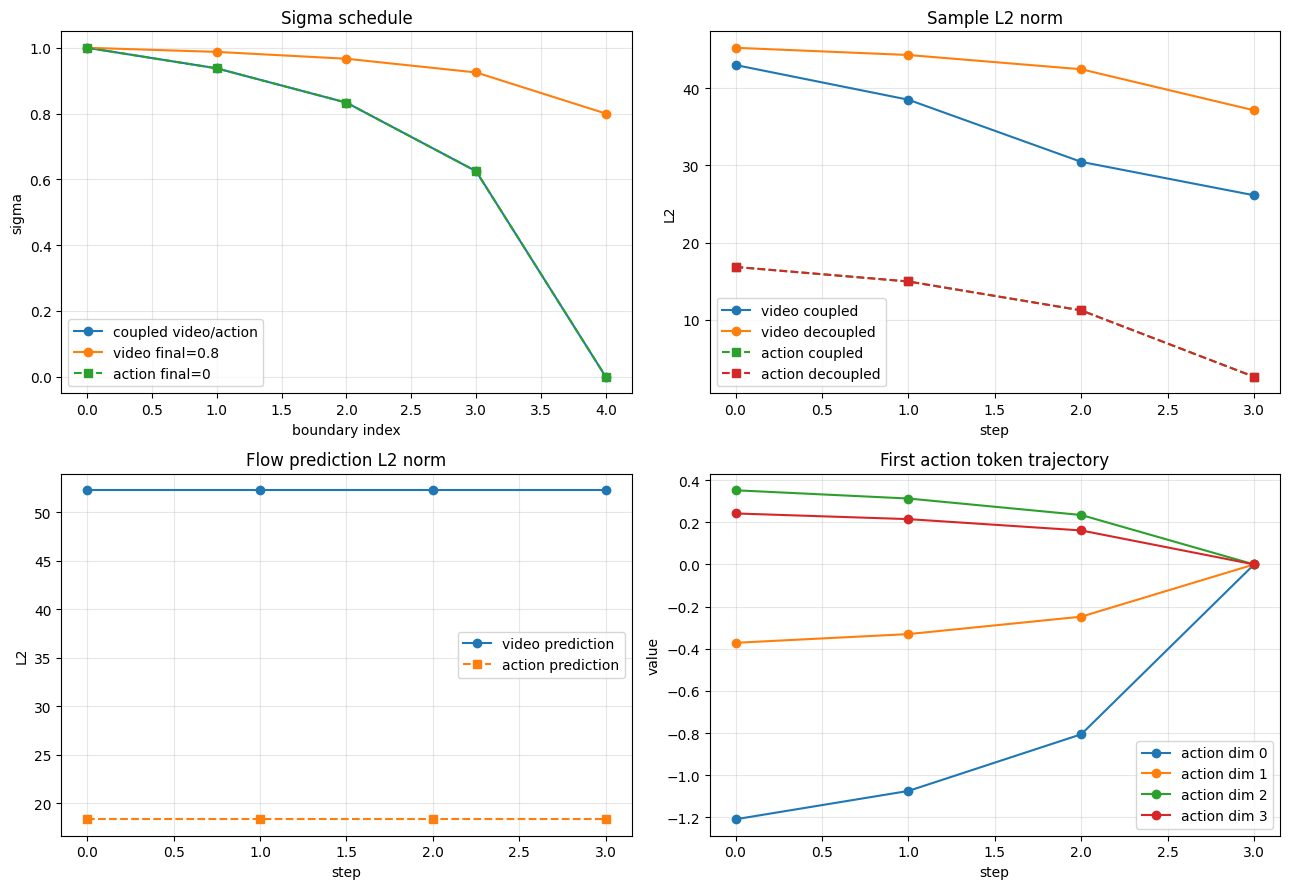

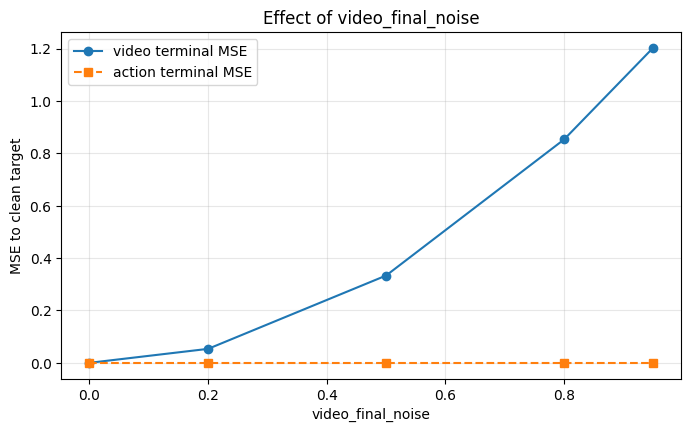

In [11]:
def values(result: dict, key: str) -> list[float]:
    return [row[key] for row in result["history"]]


steps = list(range(CFG.num_inference_steps))
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Sigma 曲线包含最后一个边界点。
axes[0, 0].plot(
    range(CFG.num_inference_steps + 1),
    coupled_result["video_scheduler"].sigmas.detach().cpu(),
    "o-", label="coupled video/action",
)
axes[0, 0].plot(
    range(CFG.num_inference_steps + 1),
    decoupled_result["video_scheduler"].sigmas.detach().cpu(),
    "o-", label=f"video final={CFG.video_final_noise}",
)
axes[0, 0].plot(
    range(CFG.num_inference_steps + 1),
    decoupled_result["action_scheduler"].sigmas.detach().cpu(),
    "s--", label="action final=0",
)
axes[0, 0].set(title="Sigma schedule", xlabel="boundary index", ylabel="sigma")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

axes[0, 1].plot(steps, values(coupled_result, "video_l2"), "o-", label="video coupled")
axes[0, 1].plot(steps, values(decoupled_result, "video_l2"), "o-", label="video decoupled")
axes[0, 1].plot(steps, values(coupled_result, "action_l2"), "s--", label="action coupled")
axes[0, 1].plot(steps, values(decoupled_result, "action_l2"), "s--", label="action decoupled")
axes[0, 1].set(title="Sample L2 norm", xlabel="step", ylabel="L2")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[1, 0].plot(steps, values(decoupled_result, "video_pred_l2"), "o-", label="video prediction")
axes[1, 0].plot(steps, values(decoupled_result, "action_pred_l2"), "s--", label="action prediction")
axes[1, 0].set(title="Flow prediction L2 norm", xlabel="step", ylabel="L2")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

action_trace = np.stack([row["action_0"] for row in decoupled_result["history"]])
for dim in range(min(4, CFG.action_dim)):
    axes[1, 1].plot(steps, action_trace[:, dim], marker="o", label=f"action dim {dim}")
axes[1, 1].set(title="First action token trajectory", xlabel="step", ylabel="value")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 扫描不同 Video 终止噪声；Action schedule 始终保持到 0。
final_noise_values = [0.0, 0.2, 0.5, 0.8, 0.95]
noise_sweep = {}
for final_noise in final_noise_values:
    noise_sweep[final_noise] = denoise_loop(
        decouple_inference_noise=True,
        video_final_noise=final_noise,
        verbose=False,
    )

video_terminal_mse = [
    noise_sweep[x]["history"][-1]["video_mse_to_clean"]
    for x in final_noise_values
]
action_terminal_mse = [
    noise_sweep[x]["history"][-1]["action_mse_to_clean"]
    for x in final_noise_values
]

plt.figure(figsize=(8, 4.5))
plt.plot(final_noise_values, video_terminal_mse, "o-", label="video terminal MSE")
plt.plot(final_noise_values, action_terminal_mse, "s--", label="action terminal MSE")
plt.xlabel("video_final_noise")
plt.ylabel("MSE to clean target")
plt.title("Effect of video_final_noise")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 9. 验证输出形状、数值稳定性与可复现性

除了最终动作形状和有效维度裁剪，还测试 `video_final_noise=0`、接近 1、越界输入以及固定初始噪声下的可复现性。

In [12]:
final_actions = decoupled_result["noisy_actions"]
valid_actions = final_actions[..., :CFG.action_dim]
padded_actions = final_actions[..., CFG.action_dim:]

assert final_actions.shape == (B, CFG.action_horizon, CFG.max_action_dim)
assert valid_actions.shape == (B, CFG.action_horizon, CFG.action_dim)
assert torch.isfinite(final_actions).all()
assert torch.isfinite(decoupled_result["noisy_latents"]).all()

# 起始 scheduler sigma 略小于 1，而源码从纯噪声开始，因此 oracle 终点允许极小离散误差。
assert coupled_result["history"][-1]["video_mse_to_clean"] < 1e-5
assert coupled_result["history"][-1]["action_mse_to_clean"] < 1e-5
assert decoupled_result["history"][-1]["action_mse_to_clean"] < 1e-5
assert padded_actions.abs().max().item() < 1e-2
assert decoupled_result["history"][-1]["video_mse_to_clean"] > 1e-2

# 固定输入时 scheduler 应确定性复现。
repro_1 = denoise_loop(decouple_inference_noise=True, video_final_noise=0.8, verbose=False)
repro_2 = denoise_loop(decouple_inference_noise=True, video_final_noise=0.8, verbose=False)
assert torch.equal(repro_1["noisy_latents"], repro_2["noisy_latents"])
assert torch.equal(repro_1["noisy_actions"], repro_2["noisy_actions"])

# 合法边界：0 等价于完整去噪；0.99 使 Video 几乎保持噪声。
for value in (0.0, 0.99):
    scheduler = make_scheduler()
    remap_video_schedule(scheduler, value)
    assert abs(scheduler.sigmas[-1].item() - value) < 1e-6

# 非法边界必须在进入 scheduler 循环前失败。
for invalid_value in (-0.1, 1.0, 1.1):
    scheduler = make_scheduler()
    try:
        remap_video_schedule(scheduler, invalid_value)
    except ValueError as exc:
        print(f"expected ValueError for {invalid_value}: {exc}")
    else:
        raise AssertionError(f"非法 video_final_noise={invalid_value} 未触发异常")

print("所有形状、有限性、边界和可复现性检查均通过。")
print("valid action preview:\n", valid_actions[0, :3])

expected ValueError for -0.1: video_final_noise 必须满足 0 <= value < sigma_max(0.999800)，当前为 -0.1
expected ValueError for 1.0: video_final_noise 必须满足 0 <= value < sigma_max(0.999800)，当前为 1.0
expected ValueError for 1.1: video_final_noise 必须满足 0 <= value < sigma_max(0.999800)，当前为 1.1
所有形状、有限性、边界和可复现性检查均通过。
valid action preview:
 tensor([[    -0.00026,     -0.00008,      0.00008,      0.00005,      0.00028,
              0.00009,     -0.00003],
        [     0.34201,      0.32162,      0.28861,      0.24595,      0.19724,
              0.14388,      0.09176],
        [     0.64273,      0.49245,      0.28831,      0.08533,     -0.06804,
             -0.14423,     -0.14064]], device='cuda:0')


## 10. 接入 VS Code 断点调试

1. 在 `dreamzero_head.py` 的 sigma 重映射、`_single_flowmatching_step()` 和两个 scheduler `step()` 调用处设置断点。
2. 在 `flow_unipc_multistep_scheduler.py` 的 `convert_model_output()`、corrector 和 predictor 更新处设置断点。
3. 先用上面的单步入口确认 schedule，再将已经加载 checkpoint 的 `DreamZeroHead` 与真实输入传给下面的 wrapper。
4. 不要在 Notebook 中重复加载 14B 模型；优先复用已有对象，或只在有足够显存时构造。

In [13]:
import logging
from typing import Any

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
NOTEBOOK_LOGGER = logging.getLogger("dreamzero_denoising_debug")

REAL_SAMPLE_KEYS = (
    "prompt_embs",
    "clip_feas",
    "ys",
    "states",
    "embodiment_ids",
    "kv_cache",
    "kv_cache_neg",
    "crossattn_cache",
    "crossattn_cache_neg",
    "current_start_frame",
    "denoise_frames",
    "latents_dtype",
    "latents_shape",
    "num_inference_steps",
)


def describe_value(name: str, value: Any) -> str:
    if isinstance(value, torch.Tensor):
        return (
            f"{name}: shape={tuple(value.shape)}, dtype={value.dtype}, "
            f"device={value.device}, finite={bool(torch.isfinite(value).all())}"
        )
    if isinstance(value, list):
        return f"{name}: list(len={len(value)})"
    return f"{name}: {value!r}"


def debug_real_sample_action_block(
    head: DreamZeroHead,
    sample_inputs: dict[str, Any],
    *,
    break_here: bool = False,
) -> torch.Tensor:
    """调用真实 DreamZeroHead._sample_action_block 的统一断点入口。"""
    missing = [key for key in REAL_SAMPLE_KEYS if key not in sample_inputs]
    if missing:
        raise KeyError(f"sample_inputs 缺少字段: {missing}")

    for key in REAL_SAMPLE_KEYS:
        message = describe_value(key, sample_inputs[key])
        print(message)
        NOTEBOOK_LOGGER.info(message)

    if break_here:
        import debugpy
        debugpy.breakpoint()

    output = head._sample_action_block(
        **{key: sample_inputs[key] for key in REAL_SAMPLE_KEYS}
    )
    print(describe_value("output_actions", output))
    return output


print("真实模型入口已定义。用法：")
print("real_actions = debug_real_sample_action_block(head, real_sample_inputs, break_here=True)")
print("本单元只定义 wrapper，不会加载或执行 14B 模型。")

真实模型入口已定义。用法：
real_actions = debug_real_sample_action_block(head, real_sample_inputs, break_here=True)
本单元只定义 wrapper，不会加载或执行 14B 模型。


## 结论与常见检查项

- `sigmas` 比 `timesteps` 多一个元素，最后一个 sigma 是 scheduler 更新后的终点。
- 标准模式下 Video / Action schedule 相同；解耦模式只重映射 Video schedule。
- `video_final_noise=0.8` 表示 Video **不会生成干净终态**，而是停留在约 80% 噪声位置；Action 仍完整去噪。
- Video 与 Action 初始高斯噪声必须独立，且形状分别为 `[B,C,T,H,W]`、`[B,H_action,D_action]`。
- `_single_flowmatching_step()` 的 Video/Action 输出必须与两种 sample 同形状，并且是 flow prediction，不是直接的 clean sample。
- 每次新推理都必须新建或重置两个 UniPC scheduler；不要复用带有旧 `model_outputs`、`last_sample` 的实例。
- 若出现 NaN/Inf，优先检查 sigma 边界、prediction dtype、错误的 timestep shape，以及 KV cache 的 device/dtype。
- 如果只关心动作质量，Video 在 Flash 模式保持噪声是预期行为，不应把 Video terminal MSE 当作失败。

本 Notebook 已在 CUDA kernel 上完整执行并通过全部断言。